# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Workaround for scenario definition restructure.
import impl.ads.mr.mr as base_mr_module
import impl.ads.scenario.scenario_definition as scen_def_module

sys.modules["impl.scenario.scenario_definition"] = scen_def_module
sys.modules["impl.mr.mr"] = base_mr_module

from impl.ads.utils.explain import vectorize, generate_rules, model_fit, scoring

plt.style.use("default")
OUT_DIR = Path("out/exp_results/")

# Prepare data

In [2]:
exp_data = {
    'ccea-c': [
        '1770083186673-ccea-866794',
        '1770113743657-ccea-c0df4b',
        '1770141244797-ccea-fa1b37',
        '1770170873331-ccea-36ba25',
        '1770225187744-ccea-7135e7',
        '1770252820518-ccea-b98a0b',
        '1770285314059-ccea-4bee83',
        '1770313923351-ccea-9edc67',
        '1770341161164-ccea-9a38da',
        '1770374668383-ccea-5cea56',
    ],
    'ccea': [
        '1772306083018-ccea-9ec8ed',
        '1772337089769-ccea-9a74d6',
        '1772367914955-ccea-7ce7ea',
        '1772392260579-ccea-eea281',
        '1772422653593-ccea-d50407',
        '1772450688801-ccea-cb0ae1',
        '1772468319090-ccea-7d1cfa',
        '1772488560319-ccea-a20c20',
        '1772516867790-ccea-884678',
        '1772547983441-ccea-2dcdad',
    ],
    'ga': [
        '1771958606715-ga-0fd171',
        '1771990475940-ga-0e1f83',
        '1772025837171-ga-c69e32',
        '1772059684370-ga-16f548',
        '1772094754060-ga-454e34',
        '1772140130107-ga-69f752',
        '1772165885347-ga-797c6b',
        '1772231265178-ga-bb63db',
        '1772262575421-ga-606a97',
        '1772661804654-ga-b3bcd0',
    ],
    'rs': [
        '1770576147587-rs-262c8a',
        '1770606205619-rs-495169',
        '1770671276916-rs-628792',
        '1770703327488-rs-d8614d',
        '1770734389077-rs-f30327',
        '1770800734983-rs-f6dd24',
        '1770832937979-rs-cf0ff1',
        '1770875963400-rs-37e1e8',
        '1771011746713-rs-8739ec',
        '1771186004494-rs-58d1ad',
    ],
    'gawa': [
        '1771550612686-gawa-a9b457',
        '1771590353173-gawa-f33e4f',
        '1771621799314-gawa-290944',
        '1771657788332-gawa-d09f9c',
        '1771695920187-gawa-d5d07a',
        '1771732063699-gawa-2acae3',
        '1771767822402-gawa-1c7af5',
        '1771807317092-gawa-b8fefe',
        '1771847400348-gawa-d467bb',
        '1771885459668-gawa-1fdaf7',
    ],
}

projects = [proj for proj_list in exp_data.values() for proj in proj_list]
violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(f"#violations: {len(violations)}, #non-violations: {len(non_violations)}, total: {len(solutions)}")

#violations: 1967, #non-violations: 606, total: 2573


# Vectorization

In [3]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

# RuleFit

In [ ]:
rulefit = generate_rules(X, y, features)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("importance", ascending=False).style.background_gradient(cmap="viridis")

# RQ4: MASE comparison

In [4]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split


def _randomized_search(_X, _y, _model, _param_dist):
    _X_train, _X_test, _y_train, _y_test = train_test_split(_X, np.array(_y), test_size=0.2, random_state=42)
    print("Using RandomizedSearchCV with 100 iterations...")
    _random_search = RandomizedSearchCV(
        estimator=_model(random_state=42),
        param_distributions=_param_dist,
        n_iter=100,
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    print("Starting randomized search...")
    _random_search.fit(_X_train, _y_train)
    print("Randomized search completed!")
    print("Best parameters:")
    for _param, _value in _random_search.best_params_.items():
        print(f"\t{_param:<20}: {_value}")

In [5]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

_randomized_search(X, y, RandomForestRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "max_features": uniform(0.1, 0.9),
    "criterion": ["squared_error", "absolute_error"],
})

Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Randomized search completed!
Best parameters:
	criterion           : squared_error
	max_depth           : 31
	max_features        : 0.3059183489424602
	max_leaf_nodes      : 10
	min_samples_leaf    : 7
	n_estimators        : 286


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform

_randomized_search(X, y, GradientBoostingRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "criterion": ["friedman_mse", "squared_error"],
    "loss": ["squared_error", "huber"]
})

Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Randomized search completed!
Best parameters:
	criterion           : friedman_mse
	learning_rate       : 0.018634812264876996
	loss                : huber
	max_depth           : 76
	max_leaf_nodes      : 10
	min_samples_leaf    : 8
	n_estimators        : 201
	subsample           : 0.7822627011142852


In [7]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


def _get_leaf_paths(_tree):
    _children_left = _tree.tree_.children_left
    _children_right = _tree.tree_.children_right
    _path_lengths = []

    def _dfs(_node, _depth):
        if _children_left[_node] == -1 and _children_right[_node] == -1:
            _path_lengths.append(_depth)
            return
        if _children_left[_node] != -1:
            _dfs(_children_left[_node], _depth + 1)
        if _children_right[_node] != -1:
            _dfs(_children_right[_node], _depth + 1)

    _dfs(0, 0)
    return _path_lengths


metrics = defaultdict(lambda: defaultdict(list))
for _ in range(500):
    X_train, X_val, y_train, y_val = train_test_split(X, np.array(y), test_size=0.2)

    # Baseline
    y_pred_median = np.full_like(y_val, fill_value=np.median(y_train))
    mae_baseline = mean_absolute_error(y_val, y_pred_median)
    metrics["baseline"]["mae"].append(mae_baseline)

    # RuleFit
    rulefit = RuleFitRegressor(max_rules=30)
    rulefit.fit(X_train, y_train)
    y_pred_rulefit = rulefit.predict(X_val)
    mae_rulefit = mean_absolute_error(y_val, y_pred_rulefit)
    metrics["rulefit"]["mae"].append(mae_rulefit)
    metrics["rulefit"]["mase"].append(mae_rulefit / mae_baseline)
    rules = rulefit._get_rules()
    rules = rules[rules.coef != 0]
    metrics["rulefit"]["rule"].append(rules)
    feature_counts = []
    for _, row in rules.iterrows():
        if row["rule"] == "linear": feature_counts.append(1)
        feature_counts.append(len(row["rule"].split("and")))
    metrics["rulefit"]["size"].append(len(rules))
    metrics["rulefit"]["length"].append(feature_counts)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=286,
        max_depth=31,
        max_leaf_nodes=10,
        min_samples_leaf=7,
        max_features=0.3059183489424602,
        criterion="squared_error",
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_val, y_pred_rf)
    metrics["rf"]["mae"].append(mae_rf)
    metrics["rf"]["mase"].append(mae_rf / mae_baseline)
    n_leaves_rf = sum(est.tree_.n_leaves for est in rf.estimators_)
    metrics["rf"]["size"].append(n_leaves_rf)
    path_lengths_rf = [length for est in rf.estimators_ for length in _get_leaf_paths(est)]
    metrics["rf"]["length"].append(path_lengths_rf)
    assert n_leaves_rf == len(path_lengths_rf)

    # GBDT
    gbdt = GradientBoostingRegressor(
        n_estimators=201,
        max_depth=76,
        max_leaf_nodes=10,
        min_samples_leaf=8,
        subsample=0.7822627011142852,
        learning_rate=0.018634812264876996,
        criterion="friedman_mse",
        loss="huber",
    )
    gbdt.fit(X_train, y_train)
    y_pred_gbdt = gbdt.predict(X_val)
    mae_gbdt = mean_absolute_error(y_val, y_pred_gbdt)
    metrics["gbdt"]["mae"].append(mae_gbdt)
    metrics["gbdt"]["mase"].append(mae_gbdt / mae_baseline)
    n_leaves_gbdt = sum(est[0].tree_.n_leaves for est in gbdt.estimators_)
    metrics["gbdt"]["size"].append(n_leaves_gbdt)
    path_lengths_gbdt = [length for est in gbdt.estimators_ for length in _get_leaf_paths(est[0])]
    metrics["gbdt"]["length"].append(path_lengths_gbdt)
    assert n_leaves_gbdt == len(path_lengths_gbdt)

(OUT_DIR / "mae26.pkl").write_bytes(pickle.dumps(dict(metrics)))

7630719

In [5]:
metrics = pickle.loads((OUT_DIR / "mae.pkl").read_bytes())

========== RuleFit ==========
Avg. MAE:			0.7143648923992681
Avg. #rules:		28.72
Avg. rule length:	2.09
========== RF ==========
Avg. MAE:			0.6826589571829722
Avg. #rules:		1009.95
Avg. rule length:	3.91
========== GBDT ==========
Avg. MAE:			0.6723662021898074
Avg. #rules:		2010.00
Avg. rule length:	4.10


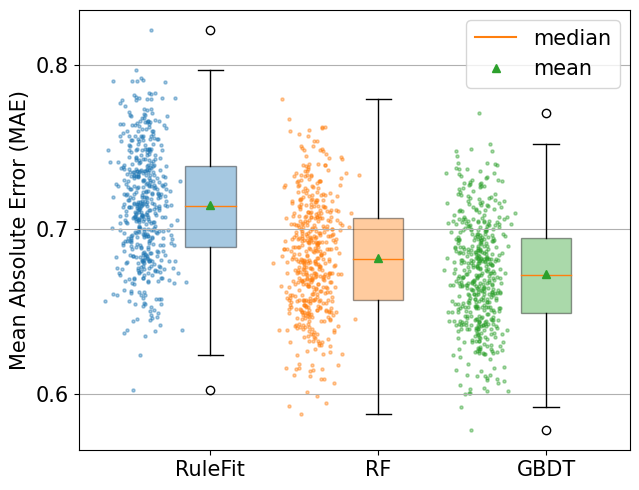

In [6]:
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
labels = ["RuleFit", "RF", "GBDT"]
values = [metrics[alg.lower()]["mae"] for alg in labels]
for alg in labels:
    print(f"========== {alg} ==========")
    print(f"Avg. MAE:\t\t\t{np.mean(metrics[alg.lower()]['mae'])}")
    print(f"Avg. #rules:\t\t{np.mean(metrics[alg.lower()]['size']):.2f}")
    print(f"Avg. rule length:\t{np.mean([np.mean(lengths) for lengths in metrics[alg.lower()]['length']]):.2f}")
bplot = ax.boxplot(values, labels=labels, showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], [f"C{i}" for i in range(10)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, value in enumerate(values):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, alpha=0.4, s=5)
ax.grid(axis="y")
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylabel("Mean Absolute Error (MAE)", fontsize=text_size)
ax.legend(handles=[
    Line2D([0], [0], c="C1", label="median"),
    Line2D([0], [0], ls="None", marker="^", mfc="C2", mec="C2", label="mean")
], fontsize=text_size)
plt.tight_layout()
plt.savefig(OUT_DIR / ".." / "visualizations" / "mae.pdf")

# RQ4: Support for the rules

In [7]:
ny = np.array(y)
X_vio = X[ny != 0]
support = []
for rule_df in metrics["rulefit"]["rule"]:
    non_linear_rules = rule_df[rule_df.type != "linear"]
    unique = set()
    for i, row in non_linear_rules.iterrows():
        rule = row["rule"]
        satisfied = X_vio.query(rule)
        unique |= set(satisfied.index)
    support.append(len(unique) / len(X_vio))

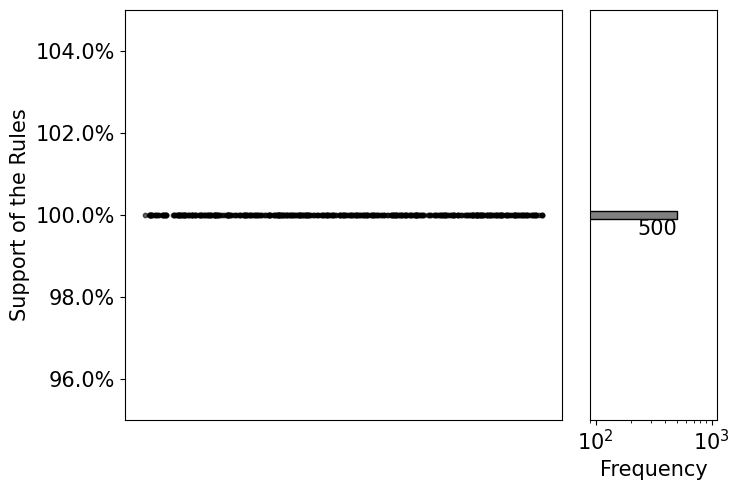

In [10]:
from matplotlib.ticker import PercentFormatter

data_x = np.random.rand(len(support))
data_y = np.array(support)
y_min = np.min(data_y)
y_max = np.max(data_y)

height = 5
text_size, tick_size = height * 3, height * 3
fig = plt.figure(figsize=(height * 1.5, height))
ax_scatter = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=4)
ax_hist_y = plt.subplot2grid((4, 4), (0, 3), rowspan=4)

if y_min == y_max:
    padding = max(abs(y_min) * 0.05, 0.01)
    bins = np.linspace(y_min - padding, y_max + padding, 50)
else:
    padding = (y_max - y_min) * 0.05
    bins = np.linspace(y_min, y_max, 50)
ax_scatter.scatter(data_x, data_y, c="k", marker="o", s=10, alpha=0.6)
ax_scatter.set_ylabel("Support of the Rules", fontsize=text_size)
ax_scatter.set_ylim(y_min - padding, y_max + padding)
ax_scatter.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_scatter.set_xticks([])
ax_scatter.tick_params(labelsize=tick_size)

hist, bin_edges, _ = ax_hist_y.hist(data_y, bins=bins,
                                    orientation="horizontal", log=True,
                                    color="gray", edgecolor="black")
ax_hist_y.set_ylim(y_min - padding, y_max + padding)
ax_hist_y.set_yticks([])
ax_hist_y.tick_params(labelsize=tick_size)
for i, (count, bin_edge) in enumerate(zip(hist, bin_edges[:-1])):
    if count > 0:
        ax_hist_y.text(count + 1, bin_edge - 0.0001, f"{int(count)}", c="black",
                       va="top", ha="right", fontsize=tick_size)
ax_hist_y.set_xlabel("Frequency", fontsize=text_size)
plt.tight_layout()
plt.savefig(OUT_DIR / ".." / "visualizations" / "support.pdf")